### Import and Connect

In [29]:
import duckdb
conn = duckdb.connect('algory.duckdb')

def load_table(name):
    return conn.sql(f"SELECT * FROM {name}").df()

##### Trades

In [30]:
trades = load_table("trades")
display(trades)

,trade_id,timestamp,strategy,symbol,side,quantity,price
0,1771616826268996,2026-02-20 14:47:06.268996,cluster_v2,AMZN,BUY,0.995579,272.049963
1,1771616826342460,2026-02-20 14:47:06.342460,pairs,GOOG,BUY,23.809667,174.883686
2,1771616826950750,2026-02-20 14:47:06.950750,momentum,GOOG,BUY,28.206942,177.261325
3,1771616827556898,2026-02-20 14:47:07.556898,mean_reversion,AAPL,BUY,5.000000,227.834405
4,1771616827556898,2026-02-20 14:47:07.556898,mean_reversion,AMZN,BUY,5.000000,266.157023
...,...,...,...,...,...,...,...
209,1771616885198171,2026-02-20 14:48:05.198171,mean_reversion,JPM,BUY,5.000000,181.959891
210,1771616885198171,2026-02-20 14:48:05.198171,mean_reversion,XOM,BUY,5.000000,73.856398
211,1771616885198171,2026-02-20 14:48:05.198171,mean_reversion,NFLX,SELL,-5.000000,156.638120
212,1771616885198171,2026-02-20 14:48:05.198171,mean_reversion,WMT,BUY,5.000000,42.180472


##### Portfolio History

In [31]:
portfolio_history = load_table("portfolio_history")
display(portfolio_history)

,timestamp,total_value,total_cash,total_positions
0,2026-02-20 14:47:08.463623,99896.617998,85628.873491,8
1,2026-02-20 14:47:10.442172,100032.047477,74567.294106,10
2,2026-02-20 14:47:12.623677,100203.787092,60435.872961,11
3,2026-02-20 14:47:14.738017,99646.218939,61082.146267,11
4,2026-02-20 14:47:16.850054,99588.641863,58623.851937,9
5,2026-02-20 14:47:18.951155,100505.957118,56956.145177,11
6,2026-02-20 14:47:21.067978,99877.535857,50621.526646,12
7,2026-02-20 14:47:23.110933,99660.330325,43137.547722,12
8,2026-02-20 14:47:25.412994,99831.662721,40243.164787,12
9,2026-02-20 14:47:27.545940,100380.632149,39109.659420,12


##### Strategy History

In [32]:
strategy_history = load_table("strategy_history")
display(strategy_history)

,timestamp,strategy,strategy_value,cash,exposure,n_positions
0,2026-02-20 14:47:08.463623,cluster_v2,25005.283985,24729.152792,276.131193,1
1,2026-02-20 14:47:08.463623,mean_reversion,24991.300373,20063.642981,4927.657392,7
2,2026-02-20 14:47:08.463623,momentum,24915.093222,20000.000000,4915.093222,1
3,2026-02-20 14:47:08.463623,pairs,24984.940418,20836.077718,4148.862700,1
4,2026-02-20 14:47:10.442172,cluster_v2,24996.106810,24729.152792,266.954018,1
...,...,...,...,...,...,...
107,2026-02-20 14:48:02.983971,pairs,28038.073824,-22902.388174,50940.461998,9
108,2026-02-20 14:48:05.198171,cluster_v2,24974.655673,22229.452391,2745.203282,7
109,2026-02-20 14:48:05.198171,mean_reversion,26316.734754,8020.295396,18296.439358,12
110,2026-02-20 14:48:05.198171,momentum,23627.591793,-35007.714678,58635.306470,12


### Plot value over time

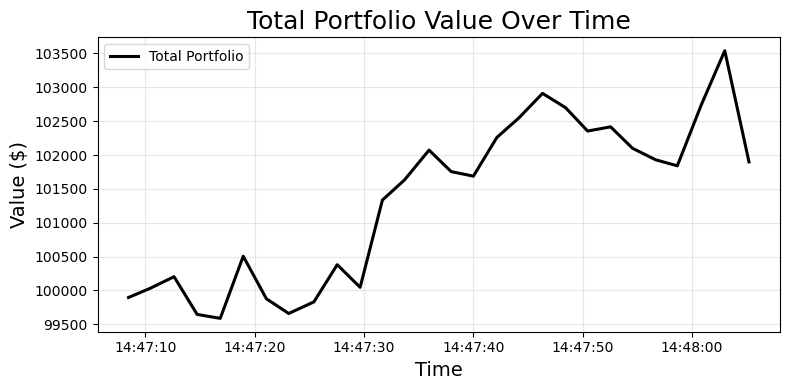

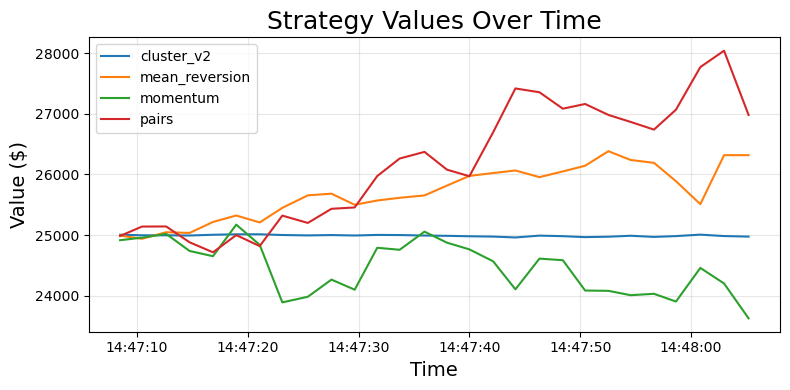

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_portfolio(portfolio: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    plt.plot(
        pd.to_datetime(portfolio["timestamp"]),
        portfolio["total_value"],
        color="black",
        linewidth=2.2,
        label="Total Portfolio"
    )

    plt.title("Total Portfolio Value Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_strategies(strategies: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    for strat, df in strategies.groupby("strategy"):
        plt.plot(
            pd.to_datetime(df["timestamp"]),
            df["strategy_value"],
            label=strat  # auto-colored
        )

    plt.title("Strategy Values Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_portfolio(portfolio_history)
plot_strategies(strategy_history)

### View portfolio metrics

##### Portfolio Stats

In [34]:
portfolio_metrics = load_table("portfolio_metrics")
display(portfolio_metrics)

,timestamp,PnL,Absolute PnL,CAGR,Max Drawdown,Sharpe Ratio,Sortino Ratio,Volatility,Value at Risk (95%),Beta to Market,Kurtosis,Average Trade Return,Median Trade Return,Win/Loss Ratio,Average Win / Average Loss
0,2026-02-20 14:47:10.442172,0.001356,135.429478,NaN,0.000000,NaN,NaN,NaN,0.001356,NaN,NaN,0.001356,0.001356,NaN,NaN
1,2026-02-20 14:47:12.623677,0.003075,307.169094,NaN,0.000000,23432.177786,NaN,0.994694,0.001374,NaN,NaN,0.001536,0.001536,NaN,NaN
2,2026-02-20 14:47:14.738017,-0.002507,-250.399059,NaN,-0.005564,-786.255164,-579.836855,15.939799,-0.004872,NaN,NaN,-0.000831,0.001356,2.000000,0.276092
3,2026-02-20 14:47:16.850054,-0.003083,-307.976135,NaN,-0.006139,-887.971643,-752.645630,13.008065,-0.004816,NaN,2.006062,-0.000767,0.000389,1.000000,0.500238
4,2026-02-20 14:47:18.951155,0.006100,609.339120,NaN,-0.006139,894.867254,1204.401158,20.650983,-0.004567,NaN,1.646432,0.001228,0.001356,1.500000,1.333254
5,2026-02-20 14:47:21.067978,-0.000191,-19.082142,NaN,-0.006253,-12.693164,-14.824220,21.926315,-0.006081,NaN,0.396864,-0.000019,0.000389,1.000000,0.991033
6,2026-02-20 14:47:23.110933,-0.002365,-236.287673,NaN,-0.008414,-242.565192,-292.637669,20.303519,-0.006046,NaN,1.032112,-0.000327,-0.000578,0.750000,1.124141
7,2026-02-20 14:47:25.412994,-0.000650,-64.955277,NaN,-0.008414,-55.863465,-63.088666,18.888225,-0.006012,NaN,0.979276,-0.000071,0.000389,1.000000,0.961103
8,2026-02-20 14:47:27.545940,0.004845,484.014151,NaN,-0.008414,427.975960,487.877632,19.058851,-0.005977,NaN,-0.151313,0.000548,0.001356,1.250000,1.070827
9,2026-02-20 14:47:29.641188,0.001501,149.940559,NaN,-0.008414,128.575288,149.143018,18.591643,-0.005943,NaN,-0.088317,0.000160,0.000389,1.000000,1.089631


##### Strategy Stats

In [35]:
strategy_metrics = load_table("strategy_metrics")
display(strategy_metrics)

,timestamp,strategy,PnL,Absolute PnL,CAGR,Max Drawdown,Sharpe Ratio,Sortino Ratio,Volatility,Value at Risk (95%),Beta to Market,Kurtosis,Average Trade Return,Median Trade Return,Win/Loss Ratio,Average Win / Average Loss
0,2026-02-20 14:47:10.442172,cluster_v2,-0.000367,-9.177175,NaN,-0.000367,NaN,-3993.749042,NaN,-0.000367,NaN,NaN,-0.000367,-0.000367,0.000000,NaN
1,2026-02-20 14:47:10.442172,mean_reversion,-0.002117,-52.905121,NaN,-0.002117,NaN,-3993.732372,NaN,-0.002117,NaN,NaN,-0.002117,-0.002117,0.000000,NaN
2,2026-02-20 14:47:10.442172,momentum,0.001703,42.425496,NaN,0.000000,NaN,NaN,NaN,0.001703,NaN,NaN,0.001703,0.001703,NaN,NaN
3,2026-02-20 14:47:10.442172,pairs,0.006207,155.086278,NaN,0.000000,NaN,NaN,NaN,0.006207,NaN,NaN,0.006207,0.006207,NaN,NaN
4,2026-02-20 14:47:12.623677,cluster_v2,-0.000368,-9.199979,NaN,-0.000368,-2768.000475,-2761.111509,1.008321,-0.000349,NaN,NaN,-0.000184,-0.000184,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2026-02-20 14:48:02.983971,pairs,0.122199,3053.133406,NaN,-0.024750,1442.936256,2465.537266,47.082370,-0.010257,NaN,-0.742145,0.004514,0.001868,1.363636,1.926865
104,2026-02-20 14:48:05.198171,cluster_v2,-0.001225,-30.628312,NaN,-0.002087,-341.641737,-402.077250,1.989921,-0.000713,NaN,0.209959,-0.000045,-0.000185,0.588235,1.367134
105,2026-02-20 14:48:05.198171,mean_reversion,0.053036,1325.434381,NaN,-0.033100,901.129745,1040.645957,32.488018,-0.010225,NaN,5.541585,0.001949,0.001725,2.000000,1.007001
106,2026-02-20 14:48:05.198171,momentum,-0.051676,-1287.501429,NaN,-0.061348,-477.024303,-505.533013,58.362932,-0.022719,NaN,0.471013,-0.001854,-0.002980,0.588235,1.219020


### Close DB

In [36]:
conn.close()